# Customer Personality Analysis

`The Customer Personality Analysis dataset provides detailed profile data of customers, including their spending habits across various categories, demographic details, and company interaction history.`

In [1]:
import math
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm


# Uploading a dataset

In [2]:
dataset_path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

df = pd.read_csv(dataset_path + "/marketing_campaign.csv", delimiter="\t")


Using Colab cache for faster access to the 'customer-personality-analysis' dataset.


In [3]:
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# Data Analysis

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## NaNs

In [5]:
df.isnull().sum()


,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


`In several rows, the Income field contains NaN, which may indicate that users have not filled in this field in the information.`

In [6]:
df[df.isnull().any(axis=1)]


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5,...,7,0,0,0,0,0,0,3,11,0
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5,...,1,0,0,0,0,0,0,3,11,0
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81,...,2,0,0,0,0,0,0,3,11,0
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48,...,6,0,0,0,0,0,0,3,11,0
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11,...,6,0,0,0,0,0,0,3,11,0
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25,...,8,0,0,0,0,0,0,3,11,0
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230,...,9,0,0,0,0,0,0,3,11,0
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7,...,7,0,0,0,0,0,0,3,11,0
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445,...,1,0,0,0,0,0,0,3,11,0
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352,...,6,0,0,0,0,0,0,3,11,0


`The data with NaN is diverse, and you cannot fill the Income field with the sample median. You can't average different users in Income. Let's leave it as it is for now.`

## Current date

In [7]:
pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y").max()


Timestamp('2014-06-29 00:00:00')

`Since the dataset does not specify the date of data collection, I will assume that the current date is 2014-06-29.`

## Dataset statistics

In [8]:
df.describe()


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


## Graphs

In [9]:
def generate_graphs(columns: str, col_numb=3):
    n_cols = len(columns)
    n_col_numb = col_numb
    rows = math.ceil(n_cols / n_col_numb)

    fig, axes = plt.subplots(nrows=2*rows, ncols=n_col_numb,
                             figsize=(5*n_col_numb, 5*rows),
                             gridspec_kw={'hspace': 0.35})


    for i, name_col in enumerate(columns):
        row = i // n_col_numb
        col = i % n_col_numb
        sns.histplot(df[name_col], kde=True, ax=axes[row*2, col])
        sns.boxenplot(data=df[name_col], orient="h", ax=axes[1+row*2, col])

        axes[row*2, col].set_xlabel("")
        axes[row*2, col].set_title(name_col)

        axes[1+row*2, col].set_xlabel("")


    for j in range(n_cols, n_col_numb * rows):
        row = j // n_col_numb
        col = j % n_col_numb
        fig.delaxes(axes[row*2, col])
        fig.delaxes(axes[1+row*2, col])

    plt.show()


In [10]:
def generate_pie(values: list,
                 indexes: list,
                 explode: list,
                 pos: int,
                 loc: str,
                 bbox: tuple,
                 title: str):
    plt.subplot(3, 2, pos)

    plt.pie(
        x=values,
        labels=indexes,
        colors=sns.color_palette("hls", len(values)),
        autopct='%.0f%%',
        shadow=True,
        explode=explode
    )
    plt.title(title)
    plt.legend(labels=[f"{name}: {value}" for name, value in zip(indexes, values)],
               loc=loc,
               bbox_to_anchor=bbox)


### Distribution personal numerical features

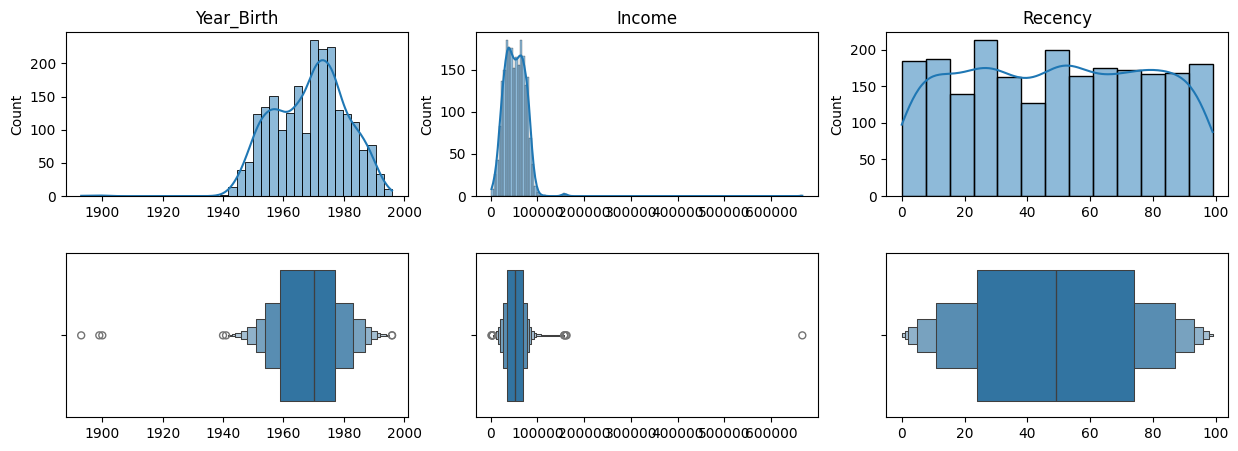

In [11]:
clomns_to_plot_personal = ['Year_Birth', 'Income', 'Recency']
generate_graphs(clomns_to_plot_personal)


`There are people who are information around 100 years old or more. There is one outlier or abnormally large value in Income.`

### Distribution categorial features

In [12]:
education = df["Education"].value_counts()
martial = df["Marital_Status"].value_counts()
kidhome = df["Kidhome"].value_counts()
teenhome = df["Teenhome"].value_counts()

customer_dt_year = df["Dt_Customer"].str.extract(r'(\d{4})$').value_counts()
complain = df["Complain"].value_counts()


In [13]:
edu_values = education.values.tolist()
edu_indexes = education.index.tolist()


In [14]:
mar_values = martial.values.tolist()
mar_indexes = martial.index.tolist()

mar_values[1], mar_values[-1] = mar_values[-1], mar_values[1]
mar_indexes[1], mar_indexes[-1] = mar_indexes[-1], mar_indexes[1]

mar_values[3], mar_values[-2] = mar_values[-2], mar_values[3]
mar_indexes[3], mar_indexes[-2] = mar_indexes[-2], mar_indexes[3]

mar_values[-3], mar_values[-2] = mar_values[-2], mar_values[-3]
mar_indexes[-3], mar_indexes[-2] = mar_indexes[-2], mar_indexes[-3]


In [15]:
kid_values = kidhome.values.tolist()
kid_indexes = kidhome.index.tolist()


In [16]:
teen_values = teenhome.values.tolist()
teen_indexes = teenhome.index.tolist()


In [17]:
customer_values = customer_dt_year.values.tolist()
customer_indexes = [int(dt[0]) for dt in customer_dt_year.index.tolist()]


In [18]:
comp_values = complain.values.tolist()
comp_indexes = complain.index.tolist()


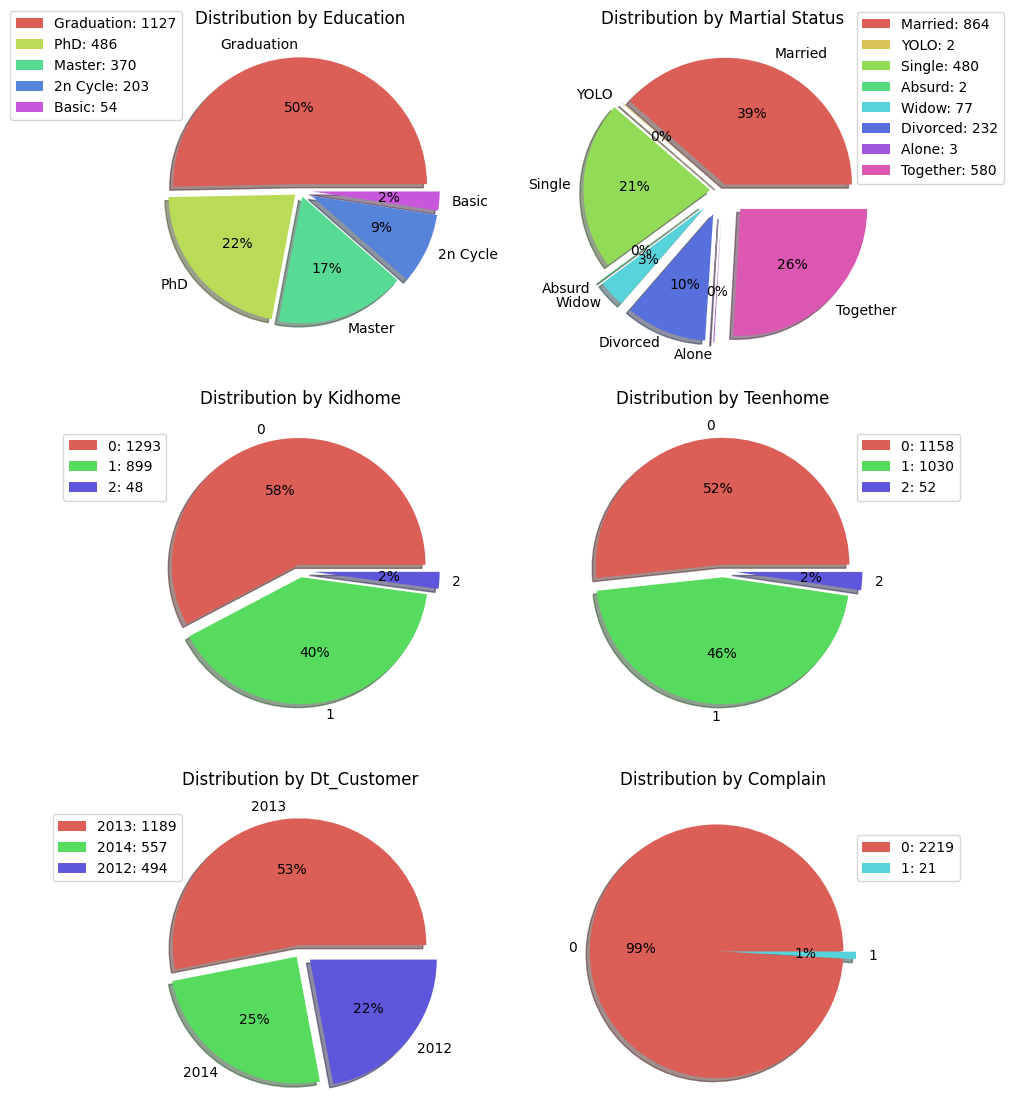

In [19]:

plt.figure(figsize=(10, 14))

generate_pie(edu_values, edu_indexes, [0.05, 0.05, 0.05, 0.1, 0.1], 1, "lower right", (0.15, 0.7), "Distribution by Education")

generate_pie(mar_values, mar_indexes, [0.05, 0.05, 0.1, 0.2, 0.2, 0.2, 0.2, 0.2], 2, "lower left", (0.9, 0.5), "Distribution by Martial Status")

generate_pie(kid_values, kid_indexes, [0.05, 0.05, 0.1], 3, "lower right", (0.1, 0.7), "Distribution by Kidhome")

generate_pie(teen_values, teen_indexes, [0.05, 0.05, 0.1], 4, "lower left", (0.9, 0.7), "Distribution by Teenhome")

generate_pie(customer_values, customer_indexes, [0.05, 0.05, 0.1], 5, "lower right", (0.15, 0.7), "Distribution by Dt_Customer")

generate_pie(comp_values, comp_indexes, [0.05, 0.05], 6, "lower left", (0.9, 0.7), "Distribution by Complain")

plt.show()


`Most customers have a higher education, and there are few customers with basic education.`

`The small YOLO and Absurd classes can be removed as they are not informative, and Alone can be merged with the Single class.`

`58% of customers do not have young children, and 52% of customers do not have teenagers.`

`There are very few complaints from customers.`

###Amount spent by product categories over the past 2 years

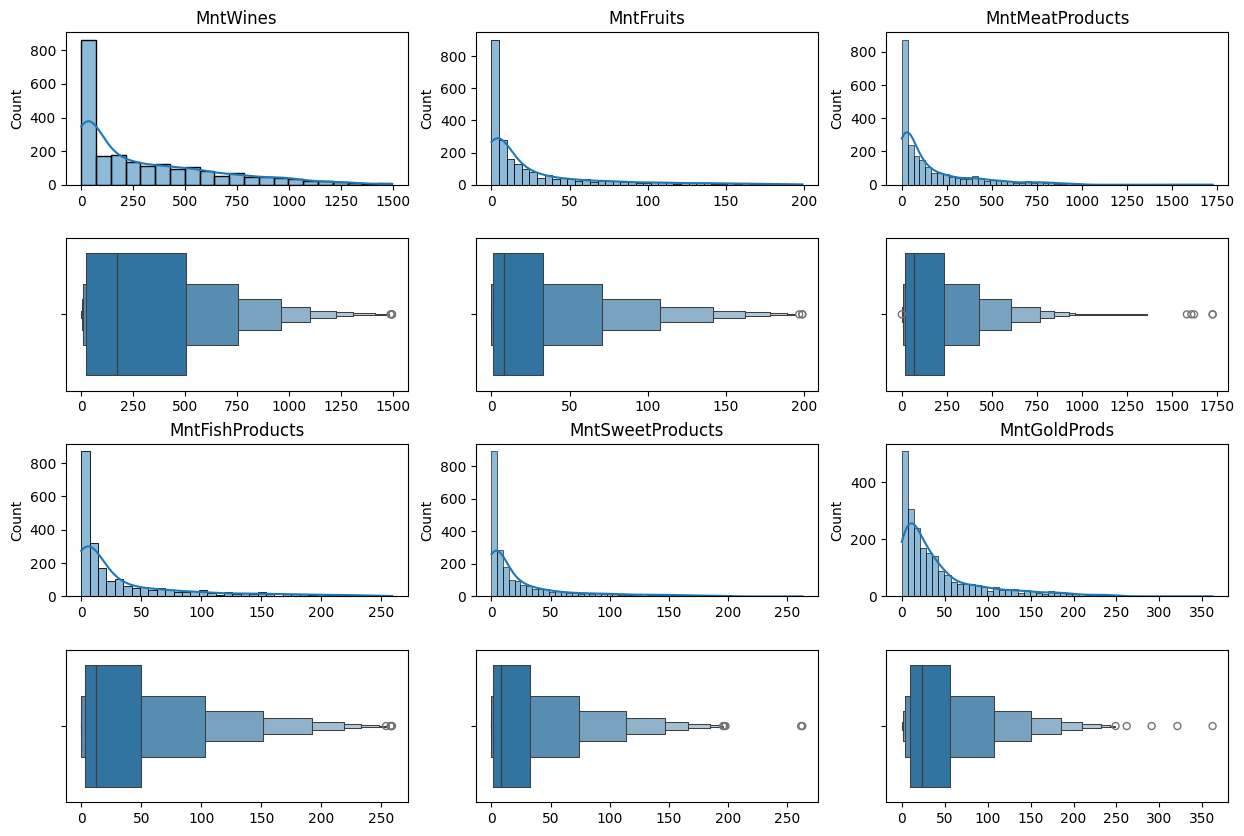

In [20]:

columns_to_plot = ['MntWines', 'MntFruits',
                   'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
                   'MntGoldProds']

generate_graphs(columns_to_plot)


`There is a logical decrease in the number of customers as the amount of money spent increases.`

###Dependence of sales on income

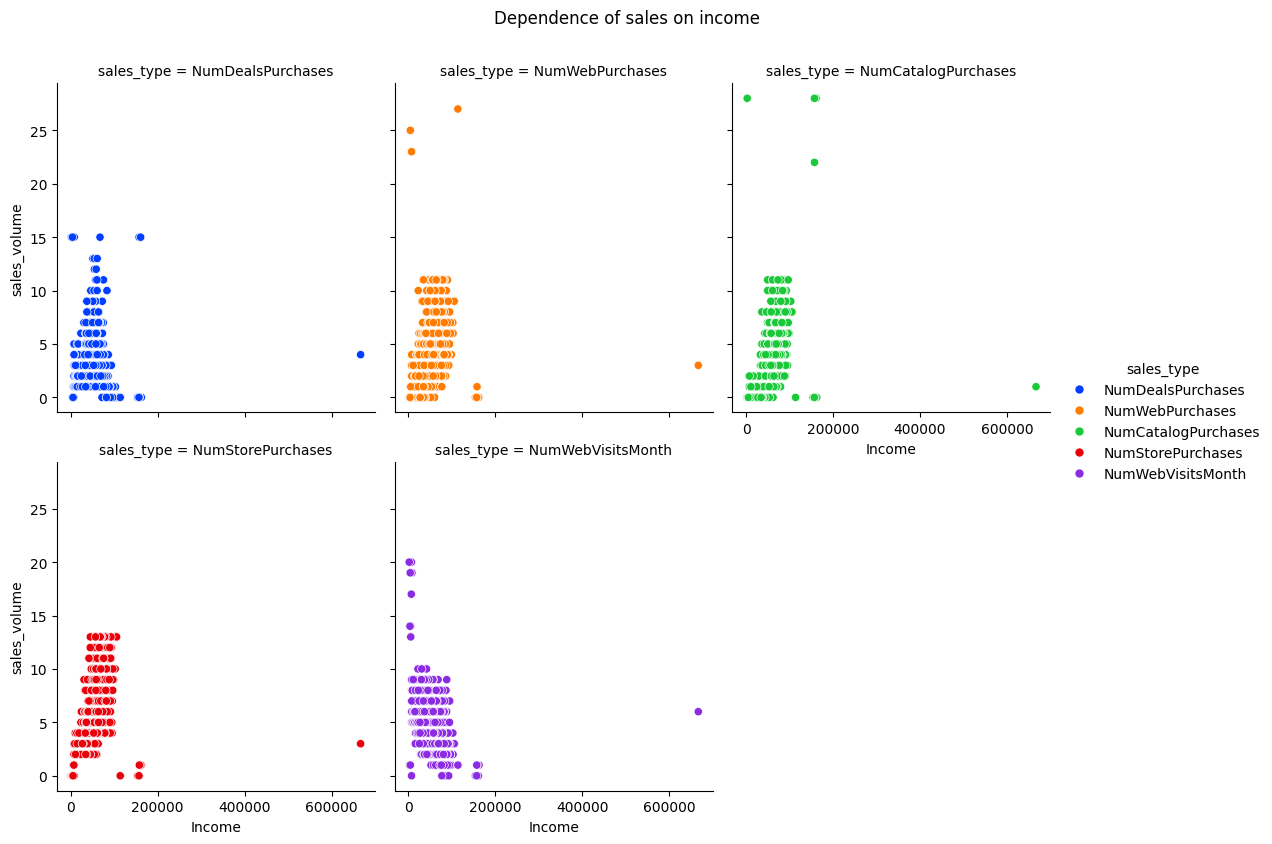

In [21]:
data = pd.melt(df,
                id_vars=['Income'],
                value_vars=['NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth'],
                var_name="sales_type",
                value_name="sales_volume")

sc = sns.relplot(data=data,
            x="Income",
            y="sales_volume",
            col="sales_type",
            kind="scatter",
            hue="sales_type",
            height=4,
            aspect=0.9,
            col_wrap=3,
            palette="bright")

sc.fig.subplots_adjust(hspace=0.15)
plt.suptitle("Dependence of sales on income", y=1.05)
plt.show()


In [22]:
df["TotalPurchases"] = df["NumCatalogPurchases"] + df["NumStorePurchases"] + df["NumWebPurchases"]
df["WebSharePurchases"] = df["NumWebPurchases"] / df["TotalPurchases"]
df["StoreSharePurchases"] = df["NumStorePurchases"] / df["TotalPurchases"]
df["CatalogSharePurchases"] = df["NumCatalogPurchases"] / df["TotalPurchases"]

df["WebSharePurchases"] = df["WebSharePurchases"].fillna(0)
df["StoreSharePurchases"] = df["StoreSharePurchases"].fillna(0)
df["CatalogSharePurchases"] = df["CatalogSharePurchases"].fillna(0)


`Fixed a possible division by 0 by filling the resulting NaN values with zeros.`

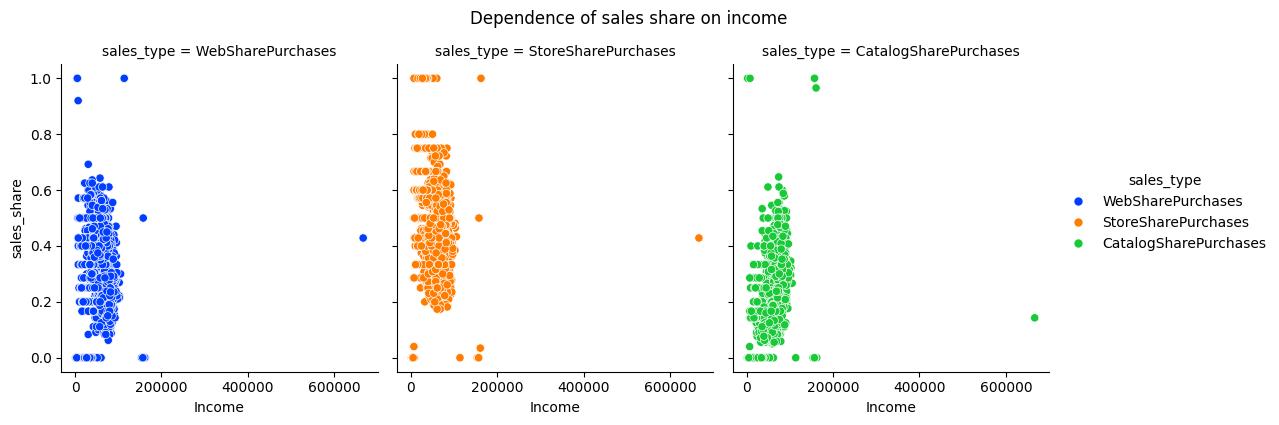

In [23]:
data_s = pd.melt(df,
                id_vars=['Income'],
                value_vars=['WebSharePurchases', 'StoreSharePurchases', 'CatalogSharePurchases'],
                var_name="sales_type",
                value_name="sales_share")

scs = sns.relplot(data=data_s,
            x="Income",
            y="sales_share",
            col="sales_type",
            kind="scatter",
            hue="sales_type",
            height=4,
            aspect=0.9,
            col_wrap=3,
            palette="bright")

scs.fig.subplots_adjust(hspace=0.15)
plt.suptitle("Dependence of sales share on income", y=1.05)
plt.show()


`There is no specific relationship between places of purchase and Income. There is a relationship between the number of discounted items and Income, with richer individuals purchasing fewer discounted items. Also, poorer people visit the Web slightly more often per month than richer people. Statistics also show that people are more likely to buy online than in physical stores.`

### Dependence of place on children

In [24]:
df["Children"] = df["Kidhome"] + df["Teenhome"]


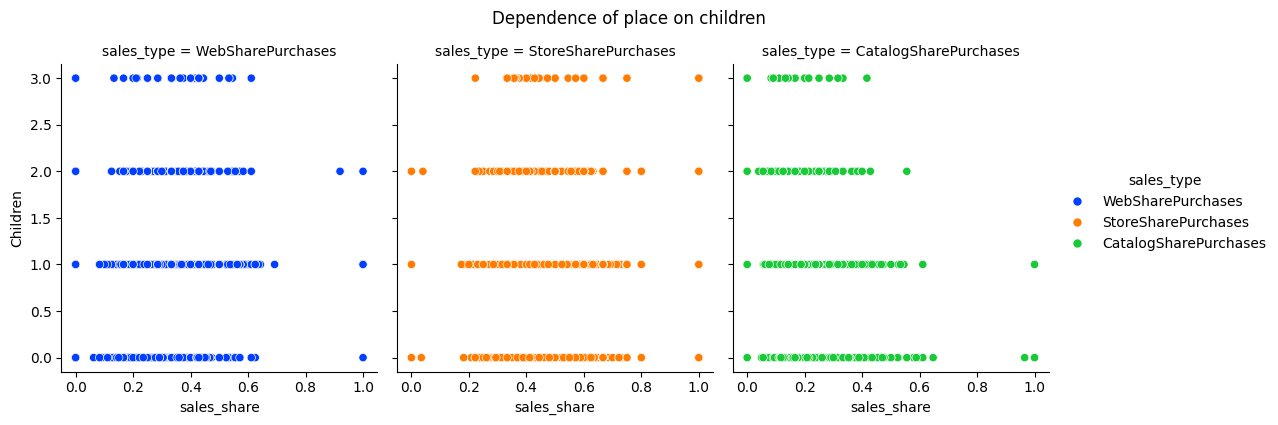

In [25]:
data_c = pd.melt(df,
                id_vars=['Children'],
                value_vars=['WebSharePurchases', 'StoreSharePurchases', 'CatalogSharePurchases'],
                var_name="sales_type",
                value_name="sales_share")

scc = sns.relplot(data=data_c,
            y="Children",
            x="sales_share",
            col="sales_type",
            kind="scatter",
            hue="sales_type",
            height=4,
            aspect=0.9,
            col_wrap=3,
            palette="bright")

scc.fig.subplots_adjust(hspace=0.15)
plt.suptitle("Dependence of place on children", y=1.05)
plt.show()


`The number of children has affected the share of purchases in Catalog, but has had almost no effect on the share of purchases in Web and Store.`

###Dependence of TotalPurchases and Income on Children

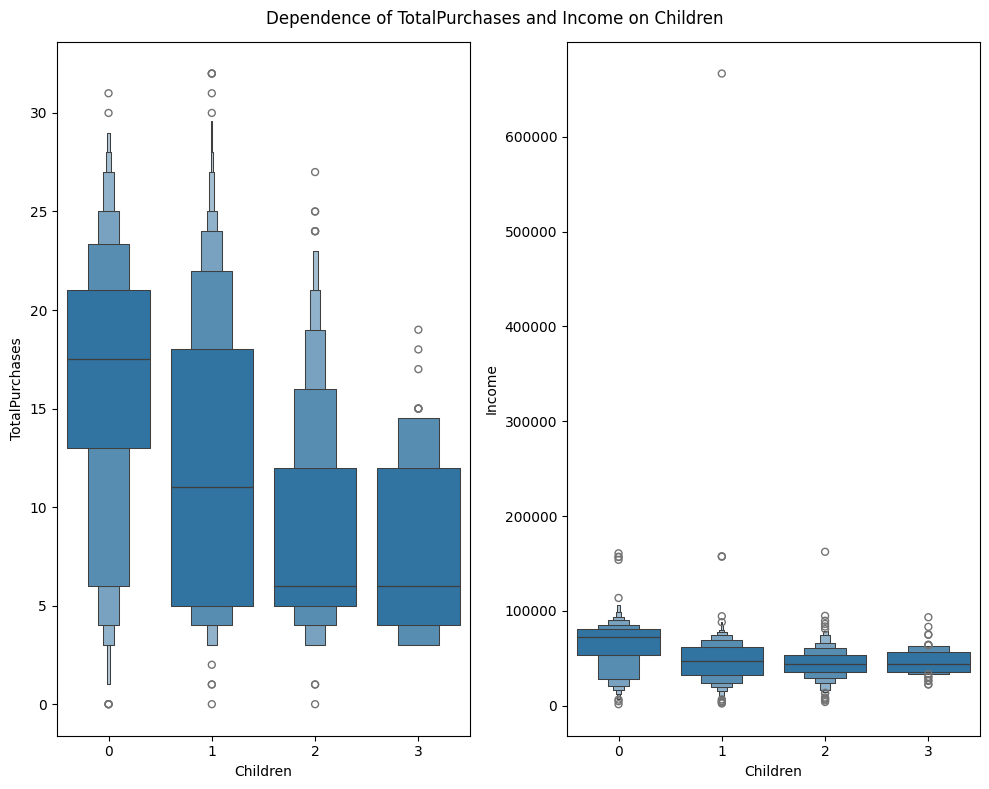

In [26]:
plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
sns.boxenplot(x="Children", y="TotalPurchases", data=df)

plt.subplot(1, 2, 2)
sns.boxenplot(x="Children", y="Income", data=df)

plt.suptitle("Dependence of TotalPurchases and Income on Children")

plt.tight_layout()
plt.show()


`The number of children affects the number of purchases and the amount spent, resulting in a chain: more children -> lower income -> lower purchase in stores.`

###Distribution by campaigns

In [27]:
name_campaigns = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4',
       'AcceptedCmp5', 'Response']
count_customers = [df[df[name_col] == 1].shape[0] for name_col in name_campaigns]


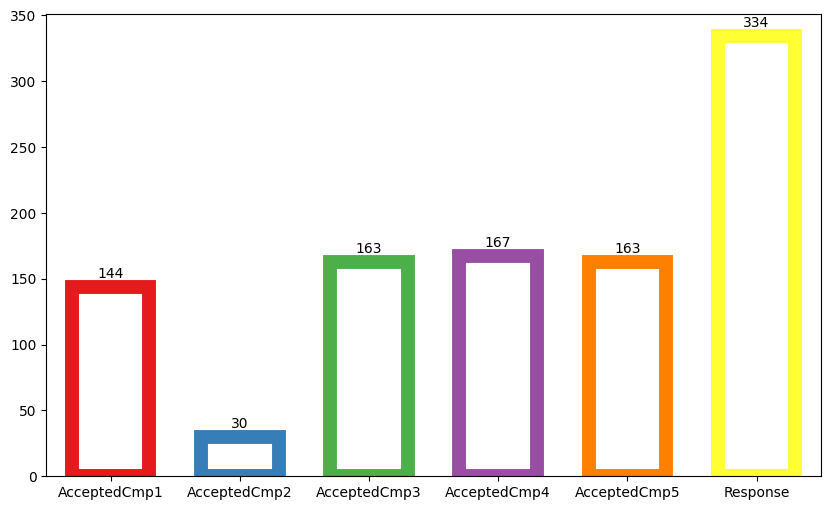

In [28]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=name_campaigns,
    y=count_customers,
    fill=False,
    palette="Set1",
    hue=name_campaigns,
    linewidth=10,
    width=0.6,
)

for container in ax.containers:
    for patch in container.patches:
        if patch.get_height() > 0:
            x_pos = patch.get_x() + patch.get_width() / 2
            y_pos = patch.get_height() + 10
            ax.text(
                x_pos, y_pos,
                f'{int(patch.get_height())}',
                ha='center', va='center',
                fontsize=10, color='black'
            )

plt.show()


`After analyzing all the campaigns, we can say that the second campaign failed, while the last one was quite successful.`

###Correlation

In [29]:
df_copy = df.drop(['ID', 'Kidhome','Teenhome',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebPurchases',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Z_CostContact', 'Z_Revenue'], axis=1)


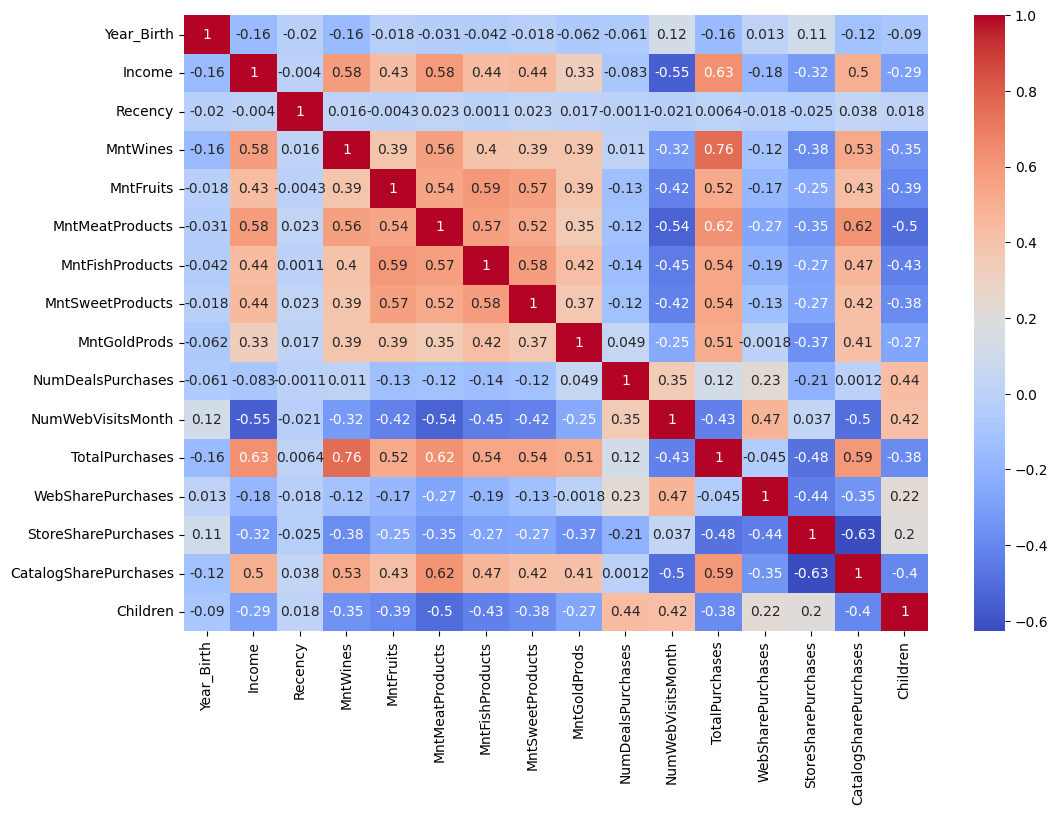

In [30]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_copy.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()


`Based on the correlation, we can say that all the connections are logical, and there are no large, unreasonable values. There is a direct relationship between TotalPurchase and meat, wine, and Income, which is logical.`

### Multicolleniarity

In [31]:
def generate_vif(df):
    df_copy_mult = sm.add_constant(df)

    vif_df = pd.DataFrame()
    vif_df["feature"] = df_copy_mult.columns
    vif_df["VIF"] = [variance_inflation_factor(df_copy_mult.values, i)
                     for i in range(df_copy_mult.shape[1])]

    return vif_df.sort_values("VIF", ascending=False)


In [32]:
df_copy_n = df_copy.select_dtypes(["number"])
df_copy_n["Income"] = df_copy_n["Income"].fillna(0)  # replaced NaN with stubs to test multicollinearity

generate_vif(df_copy_n)


,feature,VIF
0,const,29887.554088
15,CatalogSharePurchases,9.810978
14,StoreSharePurchases,9.697718
13,WebSharePurchases,6.469776
12,TotalPurchases,4.200801
4,MntWines,2.689564
6,MntMeatProducts,2.579099
11,NumWebVisitsMonth,2.464223
2,Income,2.115608
7,MntFishProducts,2.074283


`It can be seen that CatalogSharePurchases, StoreSharePurchases, and WebSharePurchases are related because they are linearly dependent and add up to 1. I delete CatalogSharePurchases.`

In [33]:
df_copy_wi = df_copy_n.drop(["CatalogSharePurchases"], axis=1)

generate_vif(df_copy_wi)


,feature,VIF
0,const,29686.598192
12,TotalPurchases,4.142974
4,MntWines,2.680674
6,MntMeatProducts,2.553403
11,NumWebVisitsMonth,2.338272
14,StoreSharePurchases,2.176635
2,Income,2.091281
7,MntFishProducts,2.073694
13,WebSharePurchases,2.022691
15,Children,1.931388


`Now multicollinearity is normal.`

#Feature engineering

##New features

- Age = 2014 - Year_Birth
- DaysInCompany = 29.06.2014 - Dt_Customer
- Children = Kidhome + Teenhome
- TotalPurchases = NumWebPurchases + NumCatalogPurchases +  NumStorePurchases
- TotalMnt = MntWines + MntFruits + MntMeatProducts + MntFishProducts + MntSweetProducts + MntGoldProds
- TotalAcceptedCmp = AcceptedCmp1 + AcceptedCmp2 + AcceptedCmp3 + AcceptedCmp4 + AcceptedCmp5 + Response
- WebSharePurchases = NumWebPurchases / TotalPurchases
- StoreSharePurchases = NumStorePurchases / TotalPurchases
- CatalogSharePurchases = NumCatalogPurchases / TotalPurchases

In [34]:
df["Age"] = 2014 - df["Year_Birth"]

df["DaysInCompany"] = (datetime(2014, 6, 29) - pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")).dt.days.astype(int)

df["TotalAcceptedCmp"] = df["AcceptedCmp1"] + df["AcceptedCmp2"] + df["AcceptedCmp3"] + df["AcceptedCmp4"] + df["AcceptedCmp5"] + df["Response"]

df["TotalMnt"] = df["MntFishProducts"] + df["MntFruits"] + df["MntGoldProds"] + df["MntMeatProducts"] + df["MntSweetProducts"] + df["MntWines"]


##Delete extra features

In [35]:
df_result = df.drop(['ID', 'Kidhome', 'Year_Birth',
       'Teenhome', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Z_CostContact', 'Z_Revenue', 'Response', 'CatalogSharePurchases', 'Dt_Customer'], axis=1)


In [36]:
df_result.head()


,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,TotalPurchases,WebSharePurchases,StoreSharePurchases,Children,Age,DaysInCompany,TotalAcceptedCmp,TotalMnt
0,Graduation,Single,58138.0,58,3,7,0,22,0.363636,0.181818,0,57,663,1,1617
1,Graduation,Single,46344.0,38,2,5,0,4,0.250000,0.500000,2,60,113,0,27
2,Graduation,Together,71613.0,26,1,4,0,20,0.400000,0.500000,0,49,312,0,776
3,Graduation,Together,26646.0,26,2,6,0,6,0.333333,0.666667,1,30,139,0,53
4,PhD,Married,58293.0,94,5,5,0,14,0.357143,0.428571,1,33,161,0,422


##Processing Outliers

###Income

In [37]:
df_result['Income'].describe(percentiles=[0.9, 0.95, 0.99])


,Income
count,2216.000000
mean,52247.251354
std,25173.076661
min,1730.000000
50%,51381.500000
90%,79844.000000
95%,84130.000000
99%,94458.800000
max,666666.000000


In [38]:
df_result[df_result["Income"] == df_result["Income"].max()]


,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,TotalPurchases,WebSharePurchases,StoreSharePurchases,Children,Age,DaysInCompany,TotalAcceptedCmp,TotalMnt
2233,Graduation,Together,666666.0,23,4,6,0,7,0.428571,0.428571,1,37,392,0,62


`According to the data, it doesn't look like an outlier. Maybe the customer has a really big income. However, it will be very difficult for the model to work with such a value, so it is better to remove.`

In [39]:
df_result_cleaned_temp = df_result[df_result["Income"] != df_result["Income"].max()]


In [40]:
df_result_cleaned_temp[df_result_cleaned_temp["Income"] < df_result_cleaned_temp["TotalMnt"]]


,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,TotalPurchases,WebSharePurchases,StoreSharePurchases,Children,Age,DaysInCompany,TotalAcceptedCmp,TotalMnt


`There are no people who have spent more than their income.`

###Age

In [41]:
df_result_cleaned_temp[df_result_cleaned_temp["Age"] >= 95]


,Education,Marital_Status,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,TotalPurchases,WebSharePurchases,StoreSharePurchases,Children,Age,DaysInCompany,TotalAcceptedCmp,TotalMnt
192,2n Cycle,Divorced,36640.0,99,1,5,1,5,0.400000,0.400000,1,114,276,0,65
239,2n Cycle,Single,60182.0,23,1,4,0,3,0.333333,0.666667,1,121,43,0,22
339,PhD,Together,83532.0,36,1,1,0,14,0.285714,0.285714,0,115,276,1,1853


`People who are over 100 years old are most likely outliers.

In [42]:
df_result_cleaned_temp1 = df_result_cleaned_temp[df_result_cleaned_temp["Age"] < 100]


###Martial Status

In [43]:
df_result_cleaned_temp2 = df_result_cleaned_temp1[~df_result_cleaned_temp1["Marital_Status"].isin(["YOLO", "Absurd"])]


In [44]:
df_result_cleaned_temp2["Marital_Status"] = df_result_cleaned_temp2["Marital_Status"].replace("Alone", "Single")


/tmp/ipykernel_786/1358811348.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_cleaned_temp2["Marital_Status"] = df_result_cleaned_temp2["Marital_Status"].replace("Alone", "Single")


`Removed the outliers and merged Alone with Single.`

###Describe data

In [45]:
df_result_cleaned_temp2.describe(percentiles=[0.8, 0.9, 0.95, 0.99])


,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,TotalPurchases,WebSharePurchases,StoreSharePurchases,Children,Age,DaysInCompany,TotalAcceptedCmp,TotalMnt
count,2208.000000,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000,2232.000000
mean,51943.520833,49.154122,2.323925,5.319892,0.008961,12.540771,0.328892,0.504246,0.951613,45.111111,353.526882,0.446237,605.624104
std,21536.756816,28.949677,1.932849,2.424993,0.094256,7.210614,0.122908,0.151622,0.752338,11.699288,202.123479,0.890094,602.123276
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,5.000000
50%,51371.000000,49.500000,2.000000,6.000000,0.000000,12.000000,0.333333,0.500000,1.000000,44.000000,355.500000,0.000000,396.000000
80%,71760.000000,79.000000,3.000000,7.000000,0.000000,20.000000,0.428571,0.600000,2.000000,57.000000,563.600000,1.000000,1173.800000
90%,79809.000000,89.000000,5.000000,8.000000,0.000000,23.000000,0.500000,0.666667,2.000000,62.000000,635.900000,2.000000,1536.000000
95%,84047.000000,94.000000,6.000000,8.000000,0.000000,24.000000,0.500000,0.750000,2.000000,64.000000,667.000000,2.000000,1768.700000
99%,94384.000000,98.000000,10.000000,9.000000,0.000000,27.690000,0.600000,1.000000,3.000000,69.000000,691.000000,4.000000,2126.000000
max,162397.000000,99.000000,15.000000,20.000000,1.000000,32.000000,1.000000,1.000000,3.000000,74.000000,699.000000,5.000000,2525.000000


`There are no more outliers.`

In [46]:
df_result_cleaned = df_result_cleaned_temp2


## Preprocessing data

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer


In [48]:
numeric_features = df_result_cleaned.select_dtypes("number").drop(["Complain"], axis=1).columns

category_features = df_result_cleaned.select_dtypes("object").columns

bool_feature = ["Complain"]


In [49]:
transformer_nums = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("imputer", KNNImputer(n_neighbors=5))
])

transformer_cat = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first"))
])

transformer_bools = FunctionTransformer(lambda x: x, feature_names_out='one-to-one')


In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", transformer_nums, numeric_features),
        ("caregory", transformer_cat, category_features),
        ("bool", transformer_bools, bool_feature)
    ]
)


#Models

In [51]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift, AffinityPropagation, Birch, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


In [52]:
df_model = df_result_cleaned.copy()


##KMeans

###Selecting the number of clusters

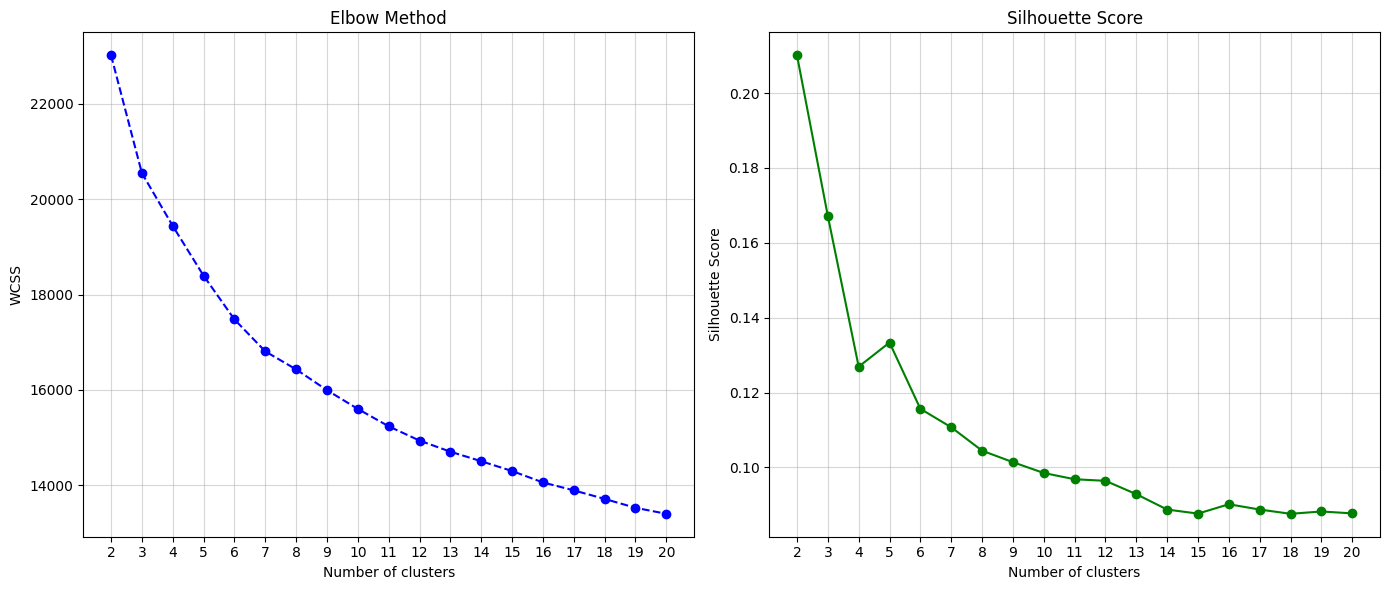

In [53]:
X_processed = preprocessor.fit_transform(df_model)

wcss = []
silhouette_scores_kmeans = []
max_k = 20

for k in range(2, max_k + 1):
    kmeans_temp = KMeans(n_clusters=k, random_state=42)
    labels = kmeans_temp.fit_predict(X_processed)
    wcss.append(kmeans_temp.inertia_)
    score = silhouette_score(X_processed, labels)
    silhouette_scores_kmeans.append(score)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(range(2, max_k + 1), wcss, marker='o', linestyle='--', color='b')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.xticks(range(2, max_k + 1))
plt.grid(True, alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(range(2, max_k + 1), silhouette_scores_kmeans, marker='o', linestyle='-', color='green')
plt.title("Silhouette Score")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, max_k + 1))
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


`I select 3 clusters based on metrics.`

###Fit

In [54]:
pipeline_kmeans = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("kmeans", KMeans(n_clusters=3, random_state=42))
])


In [55]:
pipeline_kmeans.fit(df_model)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('imputer',
                                                                   KNNImputer())]),
                                                  Index(['Income', 'Recency', 'NumDealsPurchases', 'NumWebVisitsMonth',
       'TotalPurchases', 'WebSharePurchases', 'StoreSharePurchases',
       'Children', 'Age', 'DaysInCompany', 'TotalAcceptedCmp', 'TotalMnt'],
      dtype='object')),
                                                 ('caregory',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Education', 'Marital_Status'], dtype='object')),
                                                 ('bool',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<function <lambda> at 0x7a1eb4bfda80>),
                                                  ['Complain'])])),
                ('kmeans', KMeans(n_clusters=3, random_state=42))])

In [56]:
cluster_labels = pipeline_kmeans.named_steps["kmeans"].labels_
df_result_cleaned["Cluster_KMeans"] = cluster_labels


/tmp/ipykernel_786/1680692215.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_cleaned["Cluster_KMeans"] = cluster_labels


###Principal Component Analysis

In [57]:
def generate_pca(df, hue, title="2D Principal Component Analysis (PCA)"):

    sns.scatterplot(
        x="PCA1", y="PCA2",
        hue=hue,
        data=df,
        palette="bright",
        s=60, alpha=0.8
    )
    plt.title(title)

def generate_heatmap(preprocessor, pca):
    pca_loadings = pd.DataFrame(
        pca.components_,
        columns=preprocessor.get_feature_names_out(),
        index=['PCA1', 'PCA2']
    ).T

    plt.figure(figsize=(10, 6))
    sns.heatmap(pca_loadings, cmap='coolwarm', center=0, annot=True, fmt='.3f')
    plt.title('PCA Loadings')
    plt.ylabel('Principal Components')
    plt.tight_layout()
    plt.show()


In [58]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

df_result_cleaned["PCA1"] = X_pca[:, 0]
df_result_cleaned["PCA2"] = X_pca[:, 1]


/tmp/ipykernel_786/2679330064.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_cleaned["PCA1"] = X_pca[:, 0]
/tmp/ipykernel_786/2679330064.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_cleaned["PCA2"] = X_pca[:, 1]


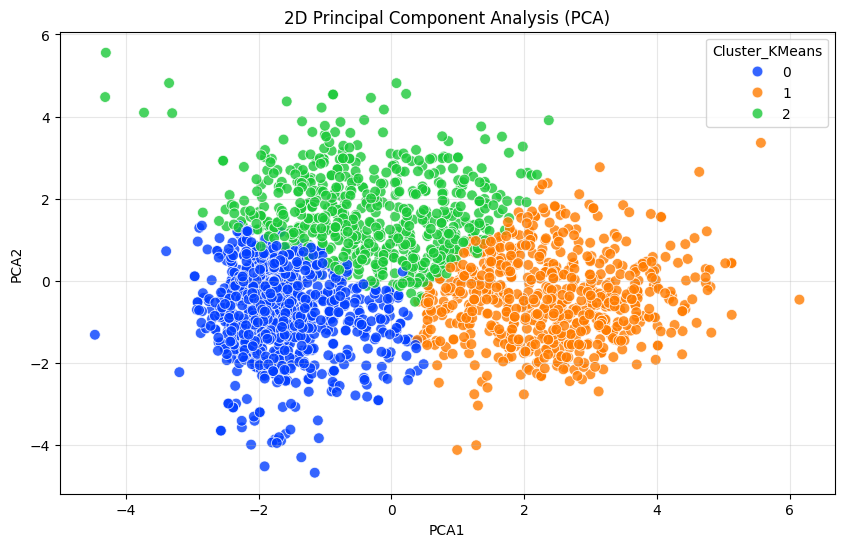

In [59]:
plt.figure(figsize=(10, 6))
generate_pca(df_result_cleaned, hue="Cluster_KMeans")
plt.grid(True, alpha=0.3)
plt.show()


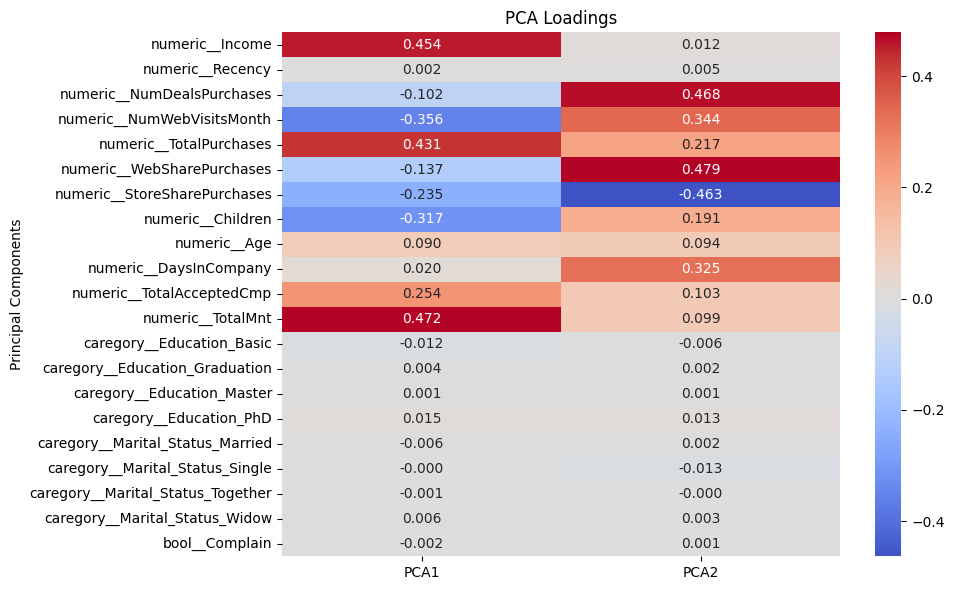

In [60]:
generate_heatmap(preprocessor, pca)


###Cluster analytics

In [61]:
cluster_profiles = df_result_cleaned.groupby("Cluster_KMeans")[
    df_model.select_dtypes("number").columns
].mean().round(2)

cluster_profiles


,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,TotalPurchases,WebSharePurchases,StoreSharePurchases,Children,Age,DaysInCompany,TotalAcceptedCmp,TotalMnt
Cluster_KMeans,,,,,,,,,,,,,
0,34582.53,49.01,1.76,6.16,0.01,5.63,0.32,0.61,1.20,42.31,295.72,0.13,89.38
1,74952.37,49.08,1.37,2.97,0.01,19.25,0.26,0.44,0.32,46.47,335.89,0.92,1279.85
2,51264.39,49.44,4.22,6.74,0.01,15.05,0.42,0.42,1.30,47.66,457.18,0.37,599.66


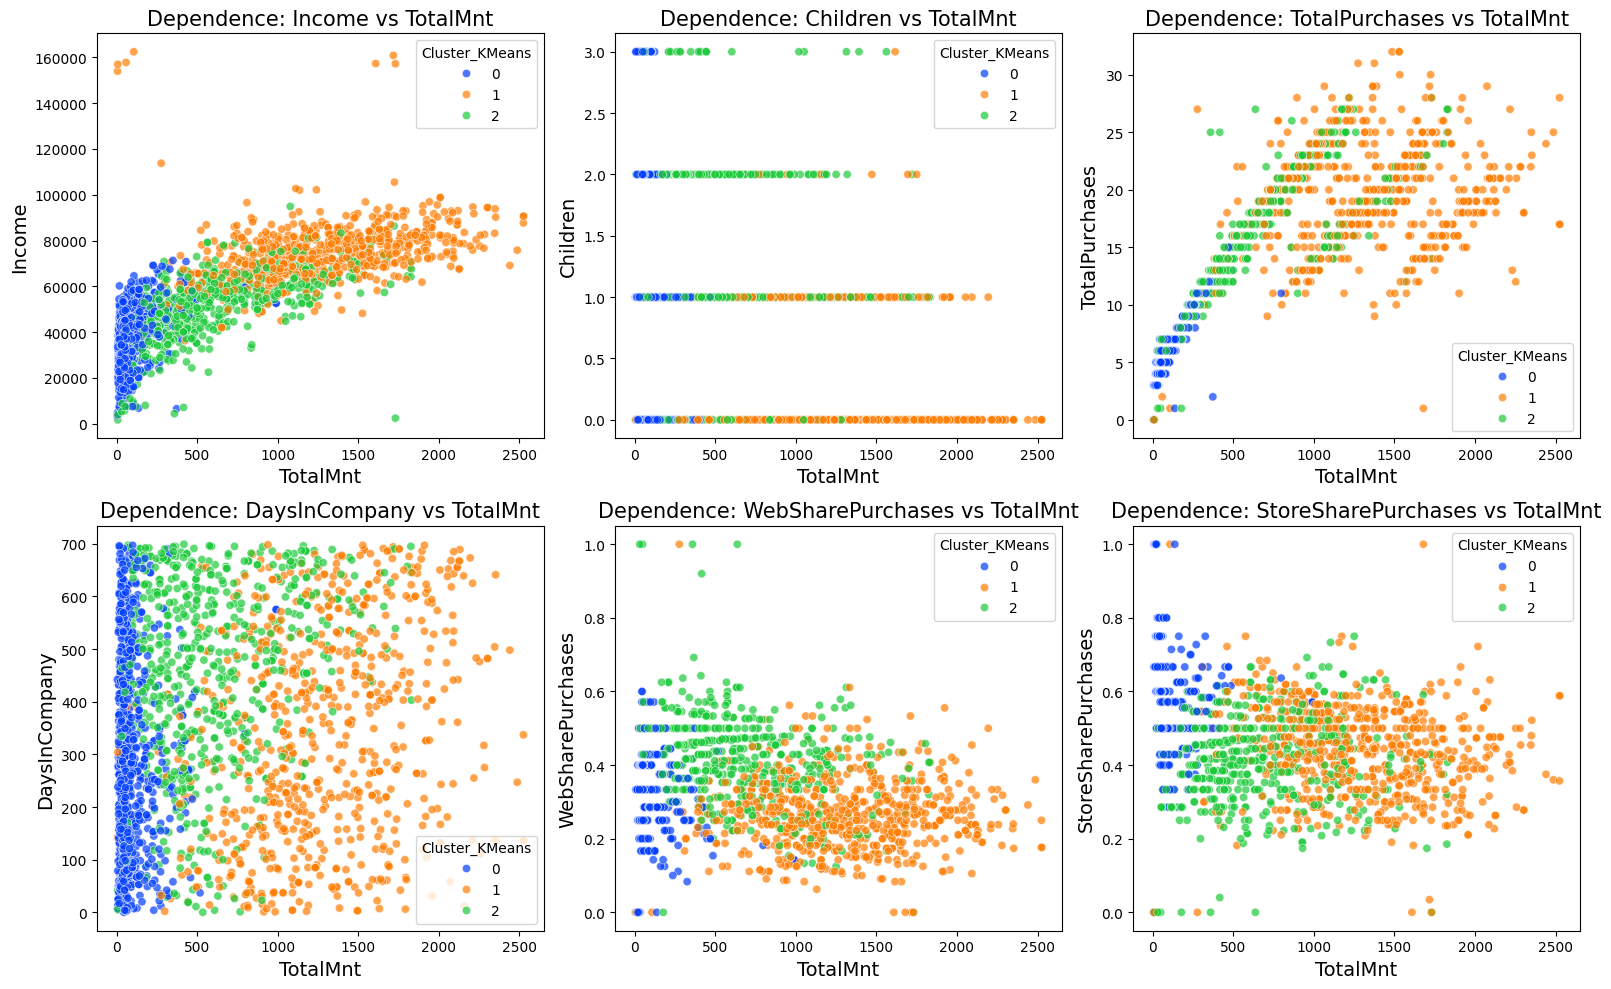

In [62]:
target_column = "TotalMnt"
comparable_columns = ['Income', 'Children', 'TotalPurchases', 'DaysInCompany', 'WebSharePurchases', 'StoreSharePurchases']

plt.figure(figsize=(16, 10))

num_col_in_row = 3
num_row = math.ceil(len(comparable_columns) / num_col_in_row)

for i, col in enumerate(comparable_columns):
    plt.subplot(num_row, num_col_in_row, i+1)
    sns.scatterplot(
        y=col,
        x=target_column,
        hue="Cluster_KMeans",
        data=df_result_cleaned,
        palette="bright",
        alpha=0.7
    )
    plt.title(f"Dependence: {col} vs {target_column}", fontdict={"fontsize": 15})
    plt.ylabel(col, fontdict={"fontsize": 14})
    plt.xlabel(target_column, fontdict={"fontsize": 14})

plt.tight_layout()
plt.show()


`Conclusions based on graphs:`
- `class 0 - people with minimal Income, who buy the least and most often in Store, and most of them have children`
- `class 1 - people with maximal Income, who spend the most and buy more often, prefer Store more often, almost no children`
- `class 2 - people with average Income, family people with children, who buy more often in Web`

##AgglomerativeClustering

###Selecting the number of clusters

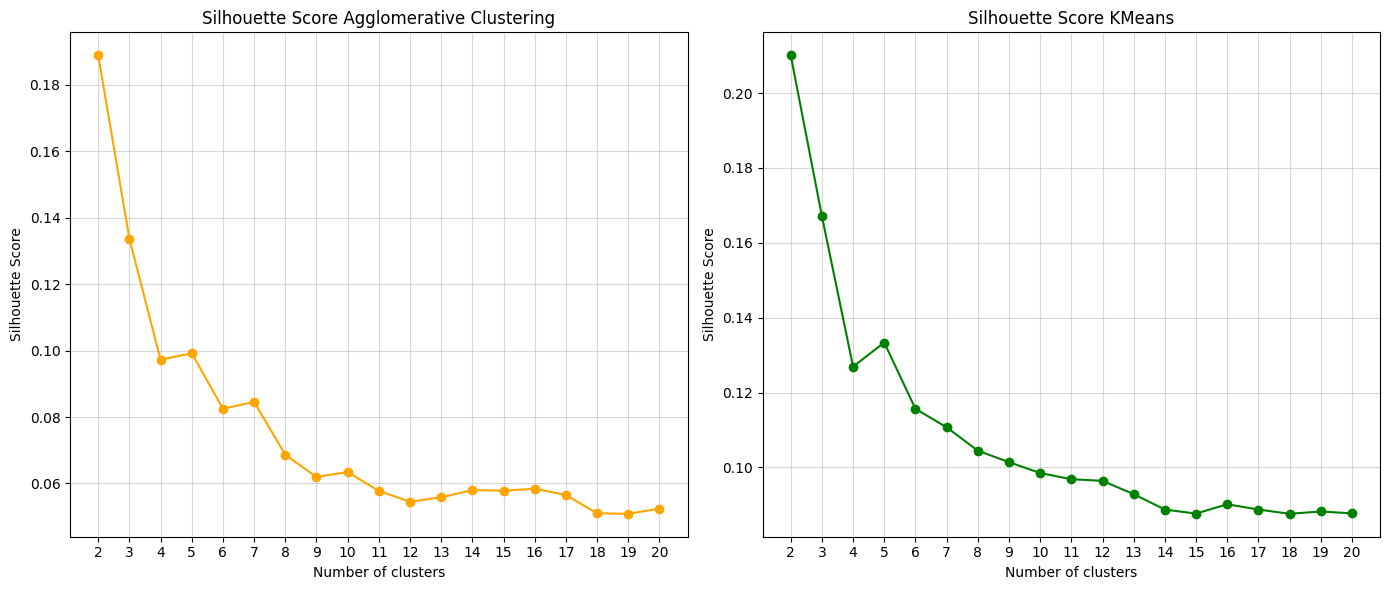

In [63]:

silhouette_scores_agl = []

for k_agl in range(2, max_k + 1):
    agl_temp = AgglomerativeClustering(n_clusters=k_agl)
    labels_agl = agl_temp.fit_predict(X_processed)
    score_agl = silhouette_score(X_processed, labels_agl)
    silhouette_scores_agl.append(score_agl)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(2, max_k + 1), silhouette_scores_agl, marker='o', linestyle='-', color='orange')
plt.title("Silhouette Score Agglomerative Clustering")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, max_k + 1))
plt.grid(True, alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(range(2, max_k + 1), silhouette_scores_kmeans, marker='o', linestyle='-', color='green')
plt.title("Silhouette Score KMeans")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, max_k + 1))
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


`The Silhouette Score of the two methods differs by about ~0.3, but also identifies three clusters (we do not take 2).`

###Fit

In [64]:
pipeline_agl= Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("aglomerative", AgglomerativeClustering(n_clusters=3))
])


In [65]:
pipeline_agl.fit(df_model)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('imputer',
                                                                   KNNImputer())]),
                                                  Index(['Income', 'Recency', 'NumDealsPurchases', 'NumWebVisitsMonth',
       'TotalPurchases', 'WebSharePurchases', 'StoreSharePurchases',
       'Children', 'Age', 'DaysInCompany', 'TotalAcceptedCmp', 'TotalMnt'],
      dtype='object')),
                                                 ('caregory',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first'))]),
                                                  Index(['Education', 'Marital_Status'], dtype='object')),
                                                 ('bool',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<function <lambda> at 0x7a1eb4bfda80>),
                                                  ['Complain'])])),
                ('aglomerative', AgglomerativeClustering(n_clusters=3))])

In [66]:
cluster_labels_agl = pipeline_agl.named_steps["aglomerative"].labels_
df_result_cleaned["Cluster_Agglomerative"] = cluster_labels_agl


/tmp/ipykernel_786/4276162382.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_cleaned["Cluster_Agglomerative"] = cluster_labels_agl


###Principal Component Analysis

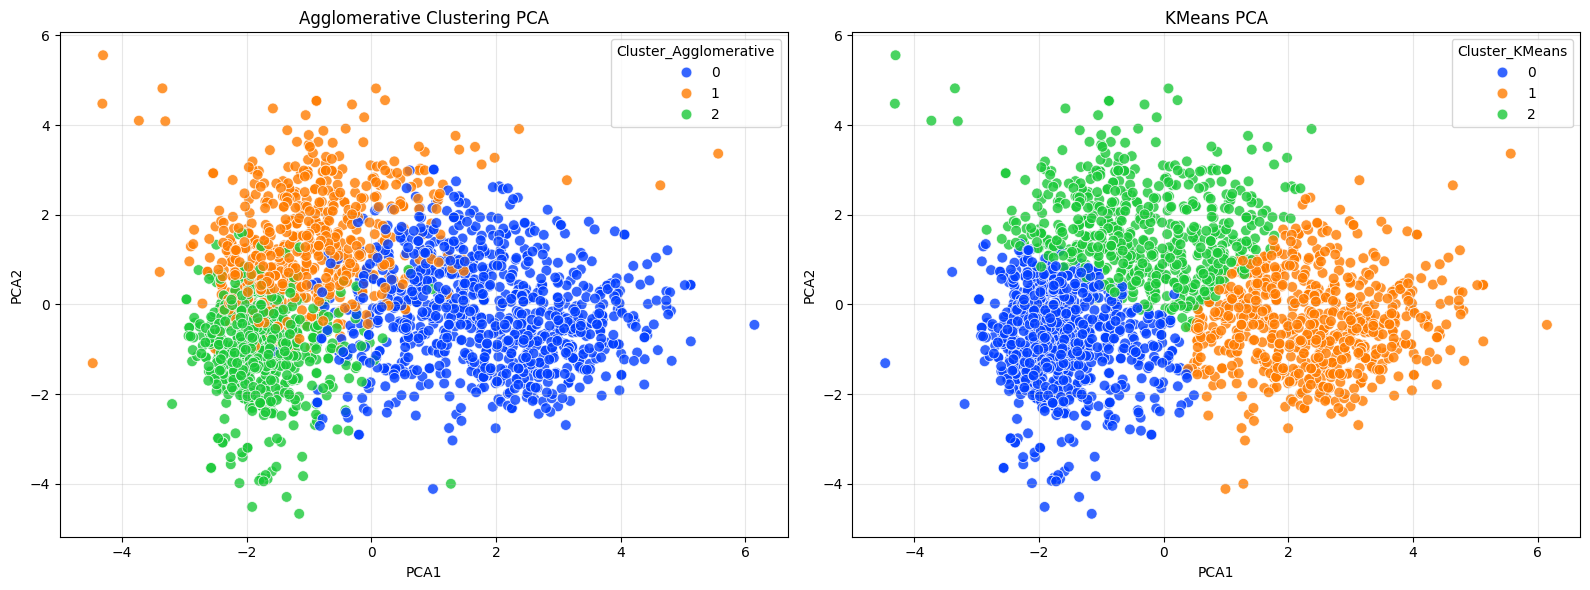

In [67]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
generate_pca(df_result_cleaned, hue="Cluster_Agglomerative", title="Agglomerative Clustering PCA")
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
generate_pca(df_result_cleaned, hue="Cluster_KMeans", title="KMeans PCA")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [68]:
cluster_profiles_agl = df_result_cleaned.groupby("Cluster_Agglomerative")[
    df_model.select_dtypes("number").columns
].mean().round(2)

cluster_profiles_agl


,Income,Recency,NumDealsPurchases,NumWebVisitsMonth,Complain,TotalPurchases,WebSharePurchases,StoreSharePurchases,Children,Age,DaysInCompany,TotalAcceptedCmp,TotalMnt
Cluster_Agglomerative,,,,,,,,,,,,,
0,70288.46,49.84,1.78,3.61,0.01,18.56,0.28,0.46,0.51,47.10,358.67,0.72,1131.02
1,40880.38,48.62,3.79,7.21,0.01,10.81,0.43,0.43,1.23,45.04,422.21,0.38,337.66
2,34867.25,48.65,1.65,6.02,0.01,5.03,0.29,0.65,1.34,42.11,274.92,0.09,70.93


`The agglomerative algorithm also produced 3 similar classes, but unlike KMeans, the classes are more mixed together. It can also be seen that the numbers of clusters 1 and 0 have changed.`

##Other models

In [69]:
dbscan = DBSCAN(eps=2.0, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_processed)

df_result_cleaned["Cluster_DBSCAN"] = labels_dbscan


/tmp/ipykernel_786/1819921703.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_cleaned["Cluster_DBSCAN"] = labels_dbscan


In [70]:
shift = MeanShift()
labels_shift = shift.fit_predict(X_processed)

df_result_cleaned["Cluster_Shift"] = labels_shift


/tmp/ipykernel_786/4025326978.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_cleaned["Cluster_Shift"] = labels_shift


In [71]:
affinity = AffinityPropagation(random_state=42)
labels_affinity = affinity.fit_predict(X_processed)

df_result_cleaned["Cluster_Affinity"] = labels_affinity


/tmp/ipykernel_786/3354615038.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_cleaned["Cluster_Affinity"] = labels_affinity


In [72]:
birch = Birch(n_clusters=3)
labels_birch= birch.fit_predict(X_processed)

df_result_cleaned["Cluster_Birch"] = labels_birch


/tmp/ipykernel_786/3443752998.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_cleaned["Cluster_Birch"] = labels_birch


In [73]:
mixture = GaussianMixture(n_components=3, random_state=42)
labels_mixture= mixture.fit_predict(X_processed)

df_result_cleaned["Cluster_GMixture"] = labels_mixture


/tmp/ipykernel_786/1533240366.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_cleaned["Cluster_GMixture"] = labels_mixture


In [74]:
spectral = SpectralClustering(n_clusters=3, n_components=2, affinity='nearest_neighbors', n_neighbors=1500)
labels_spectral= spectral.fit_predict(X_processed)

df_result_cleaned["Cluster_Spectral"] = labels_spectral


/tmp/ipykernel_786/3288838835.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_result_cleaned["Cluster_Spectral"] = labels_spectral


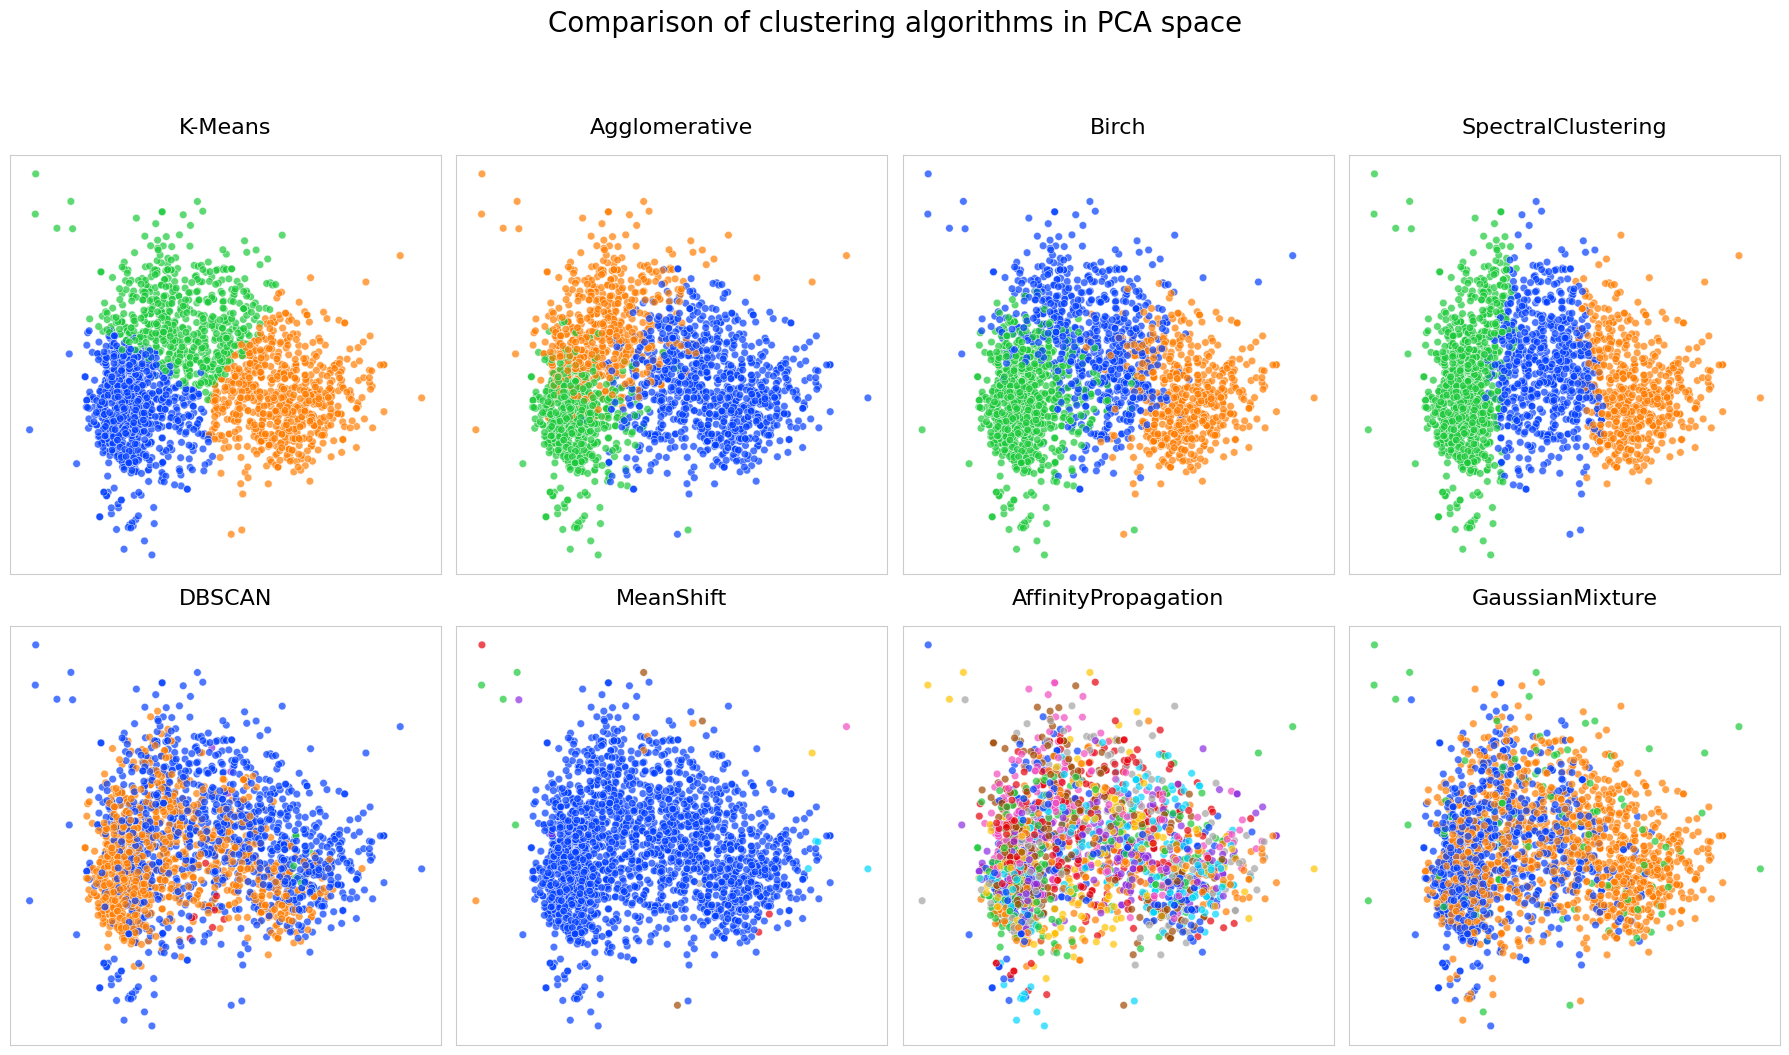

In [75]:
num_rows = 2
num_columns = 4

fig, axes = plt.subplots(num_rows, num_columns, figsize=(18, 10))

algorithms = [
    ('K-Means', 'Cluster_KMeans'),
    ('Agglomerative', 'Cluster_Agglomerative'),
    ('Birch', 'Cluster_Birch'),
    ('SpectralClustering', 'Cluster_Spectral'),
    ('DBSCAN', 'Cluster_DBSCAN'),
    ('MeanShift', 'Cluster_Shift'),
    ('AffinityPropagation', 'Cluster_Affinity'),
    ('GaussianMixture', 'Cluster_GMixture'),
]

axes_flat = axes.flatten()

for ind, (title, cluster_col) in enumerate(algorithms):

    ax_ = axes_flat[ind]

    sns.scatterplot(
        data=df_result_cleaned,
        x='PCA1',
        y='PCA2',
        hue=cluster_col,
        palette='bright',
        ax=ax_,
        s=30,
        alpha=0.7
    )

    ax_.set_title(title, fontsize=16, pad=15)

    ax_.legend_.remove() if ax_.legend_ else None

    ax_.set_xticks([])
    ax_.set_yticks([])
    ax_.set_xlabel('')
    ax_.set_ylabel('')

    for spine in ax_.spines.values():
        spine.set_color('#CCCCCC')

plt.suptitle("Comparison of clustering algorithms in PCA space", fontsize=20, y=1.05)
plt.tight_layout()
plt.show()


#Conclusion

`To summarize, this project encompassed an end-to-end customer personality analysis, including in-depth EDA, feature engineering, and model training. By comparing multiple clustering algorithms, I found that hierarchical and centroid-based methods performed best for this specific distribution.`

`Ultimately, the customer base was segmented into three distinct and actionable profiles: Wealthy Customers, Family-Oriented Customers, and Low-Income Customers. This segmentation empowers the business to shift from a mass-marketing approach to targeted strategies, allowing for personalized promotional campaigns and tailored services that resonate with the specific buying habits of each group.`